In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib import rcParams
import matplotlib.transforms as mtransforms
import numpy as np
from matplotlib.ticker import NullFormatter
import matplotlib.font_manager as fm

def on_press(event):
    print("my position:", event.button, event.xdata, event.ydata)

fontsize = 8
fonttype = 'sans-serif'
mpl.rcParams['font.size'] = fontsize
mpl.rcParams['figure.dpi'] = 150

if (fonttype == 'serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    mpl.rc('text.latex', preamble=r'\usepackage{amsmath, newtxtext, newtxmath}')
    plt.rcParams['font.family'] = 'serif'
elif (fonttype == 'sans-serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    plt.rcParams['font.family'] = 'sans-serif'
    latex_preamble = r"""
    \usepackage[T1]{fontenc}
    \usepackage{bm, amsmath, sansmathfonts}    

    \makeatletter
    \AtBeginDocument{
        \DeclareSymbolFont{sansextrabold}{T1}{cmss}{bx}{n}
        \DeclareMathSymbol{+}{\mathbin}{sansextrabold}{"2B}
        \DeclareMathSymbol{=}{\mathrel}{sansextrabold}{"3D}
        \DeclareMathSymbol{<}{\mathrel}{sansextrabold}{"3C}
        \DeclareMathSymbol{>}{\mathrel}{sansextrabold}{"3E}
        \DeclareMathSymbol{|}{\mathord}{sansextrabold}{"7C}
        \DeclareMathSymbol{/}{\mathord}{sansextrabold}{"2F}

        \DeclareSymbolFont{boldsanssymbols}{OMS}{cmsssy}{b}{n}
        \DeclareMathSymbol{-}{\mathbin}{boldsanssymbols}{"00}
        \DeclareMathSymbol{\times}{\mathbin}{boldsanssymbols}{"02}


        \DeclareMathSymbol{\oplus}{\mathbin}{boldsanssymbols}{"08}
        \DeclareMathSymbol{\otimes}{\mathbin}{boldsanssymbols}{"0A}
        \DeclareMathSymbol{\approx}{\mathrel}{boldsanssymbols}{"19}
        \DeclareMathSymbol{\perp}{\mathrel}{boldsanssymbols}{"3F}
        \DeclareMathSymbol{\sim}{\mathrel}{boldsanssymbols}{"18}
        \DeclareMathSymbol{\to}{\mathrel}{boldsanssymbols}{"21}
        \DeclareMathSymbol{\leftarrow}{\mathrel}{boldsanssymbols}{"20}
        \DeclareMathSymbol{\in}{\mathrel}{boldsanssymbols}{"32}

        \let\original@le\le
        \let\original@ge\ge
        \let\original@langle\langle
        \let\original@rangle\rangle

        \renewcommand{\le}{\bm{\original@le}}
        \renewcommand{\ge}{\bm{\original@ge}}
        \renewcommand{\langle}{\bm{\original@langle}}
        \renewcommand{\rangle}{\bm{\original@rangle}}
        \renewcommand{\|}{|\hspace{-1pt}|}
    }
    \makeatother

    \newcommand{\p}{\partial}
    \newcommand{\T}{^{\mathrm{T}}}
    \renewcommand{\vec}[1]{\boldsymbol{#1}}
    \newcommand{\bn}{\vec{\nabla}}
    \newcommand\ii{\mathrm{i}}
    \newcommand\ee{\mathrm{e}}
    \newcommand{\widebar}[1]{\mskip.5\thinmuskip\overline{\mskip-.5\thinmuskip {#1} \mskip-.5\thinmuskip}\mskip.5\thinmuskip}
    \newcommand{\ket}[1]{| #1 \rangle}
    \newcommand{\bra}[1]{\langle #1 |}
    """
    mpl.rc('text.latex', preamble=latex_preamble)

In [2]:
df = pd.read_csv(fr'data/3D/circuit_depth.csv', header=0)
nq_exp = df['nq'].tolist()
depth = df['Transpiled depth'].tolist() 

nq = np.linspace(1, 30, num=30)
model = 2 * (nq**2 + nq - 2)

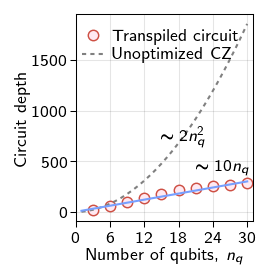

In [4]:
fig_width = 18/2.54
fig_height = 18/2.54
fig = plt.figure(figsize=(fig_width, fig_height))

ax_width = 3/2.54 / fig_width
ax_height = ax_width / 3 * 3.5

# 
ax = fig.add_axes([0, 0, ax_width, ax_height])
ax.grid(color='k', linestyle='-', linewidth=0.5, alpha=0.1)
ax.plot(nq_exp, depth, linestyle='none', marker='o', markersize=5, markerfacecolor='#FFE9F1', markeredgecolor='#CE5044', markeredgewidth=0.7, label='Transpiled circuit')
ax.plot(nq, model, linewidth=1, linestyle='--', dashes=(2, 2), color='gray', label='Unoptimized CZ')
ax.plot(nq, 10*nq, linewidth=1, linestyle='-', color="#77A0FF")

ax.text(15, 700, r'$\sim 2n_q^2$')
ax.text(21, 400, r'$\sim 10 n_q$')

ax.legend(ncol=1, frameon=False, labelspacing=0.2, handlelength=1.3, handletextpad=0.5, bbox_to_anchor=(-0.05, 1), loc='upper left', fontsize=fontsize)
plt.xlim(0, 31) 
# plt.ylim(0, 1)
plt.xlabel(r'Number of qubits, $n_q$', labelpad=1, size=fontsize)
plt.ylabel(r'Circuit depth', labelpad=1, size=fontsize) # rotation=0
ax.set_xticks(np.linspace(0, 30, 6))
# ax.set_yticklabels([r'$10^{-1}$', r'$10^0$', r'$10^1$'])
# ax.yaxis.set_minor_formatter(NullFormatter())
# ax.yaxis.set_major_formatter(NullFormatter())
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(axis='x', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1.5)
ax.tick_params(axis='y', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1)
ax.tick_params(which='minor', direction='out', top=False, right=False, length=1.5, width=0.5)

# 
plt.savefig(fr'figures/circuit_depth.pdf', transparent=True, orientation='portrait', format='pdf', bbox_inches='tight')